### Analísis Exploratorio EDA

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os


In [3]:
df= pd.read_csv('../data/raw/stroke_dataset.csv')

In [6]:
df.shape

(4981, 11)

In [8]:
df.head(20)

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
2,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
3,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
4,Male,81.0,0,0,Yes,Private,Urban,186.21,29.0,formerly smoked,1
5,Male,74.0,1,1,Yes,Private,Rural,70.09,27.4,never smoked,1
6,Female,69.0,0,0,No,Private,Urban,94.39,22.8,never smoked,1
7,Female,78.0,0,0,Yes,Private,Urban,58.57,24.2,Unknown,1
8,Female,81.0,1,0,Yes,Private,Rural,80.43,29.7,never smoked,1
9,Female,61.0,0,1,Yes,Govt_job,Rural,120.46,36.8,smokes,1


In [9]:
df.describe()

,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,4981.000000,4981.000000,4981.000000,4981.000000,4981.000000,4981.000000
mean,43.419859,0.096165,0.055210,105.943562,28.498173,0.049789
std,22.662755,0.294848,0.228412,45.075373,6.790464,0.217531
min,0.080000,0.000000,0.000000,55.120000,14.000000,0.000000
25%,25.000000,0.000000,0.000000,77.230000,23.700000,0.000000
50%,45.000000,0.000000,0.000000,91.850000,28.100000,0.000000
75%,61.000000,0.000000,0.000000,113.860000,32.600000,0.000000
max,82.000000,1.000000,1.000000,271.740000,48.900000,1.000000


In [10]:
df.describe(include=['object','category'])

C:\Users\gemit\AppData\Local\Temp\ipykernel_23804\2581907228.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include=['object','category'])


,gender,ever_married,work_type,Residence_type,smoking_status
count,4981,4981,4981,4981,4981
unique,2,2,4,2,4
top,Female,Yes,Private,Urban,never smoked
freq,2907,3280,2860,2532,1838


In [11]:
categoricas= df.select_dtypes(include=['object','category']).columns
for col in categoricas:
    print(df[col].value_counts())
    print("---")

gender
Female    2907
Male      2074
Name: count, dtype: int64
---
ever_married
Yes    3280
No     1701
Name: count, dtype: int64
---
work_type
Private          2860
Self-employed     804
children          673
Govt_job          644
Name: count, dtype: int64
---
Residence_type
Urban    2532
Rural    2449
Name: count, dtype: int64
---
smoking_status
never smoked       1838
Unknown            1500
formerly smoked     867
smokes              776
Name: count, dtype: int64
---


C:\Users\gemit\AppData\Local\Temp\ipykernel_23804\4210545713.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categoricas= df.select_dtypes(include=['object','category']).columns


In [13]:
a1,a2= df['stroke'].value_counts()
print(a1,a2)

4733 248


In [16]:
ratio= a1/a2
print(f"La proporción de personas que han sufrido un ictus es de {ratio:.0f}:1")

La proporción de personas que han sufrido un ictus es de 19:1


<Axes: xlabel='stroke', ylabel='age'>

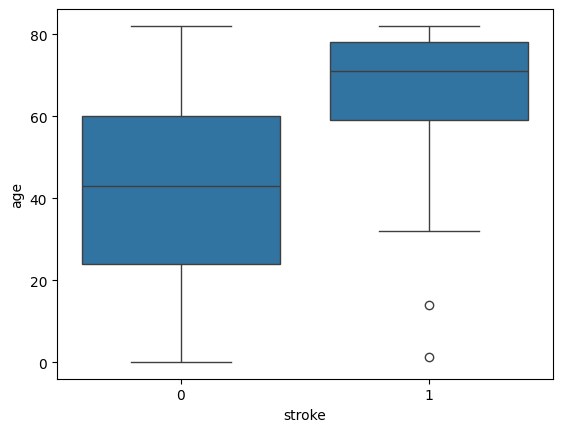

In [17]:
sns.boxplot(x='stroke', y='age', data=df)

Hemos verificado las variables clinicas de los outliers menores de 20 años que tienes ictus

In [19]:
outliers= df[(df['age']<20) & (df['stroke']==1)]
print(outliers)

      gender    age  hypertension  heart_disease ever_married work_type  \
205   Female  14.00             0              0           No  children   
4807  Female   1.32             0              0           No  children   

     Residence_type  avg_glucose_level   bmi smoking_status  stroke  
205           Rural              57.93  30.9        Unknown       1  
4807          Urban              70.37  18.7        Unknown       1  


<Axes: xlabel='stroke', ylabel='avg_glucose_level'>

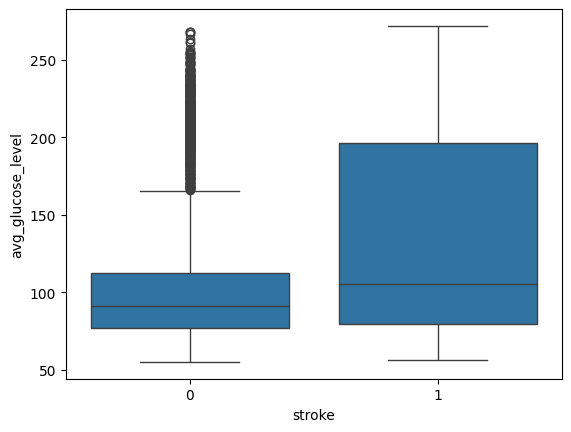

In [20]:
sns.boxplot(x='stroke', y='avg_glucose_level', data=df)

<Axes: xlabel='stroke', ylabel='bmi'>

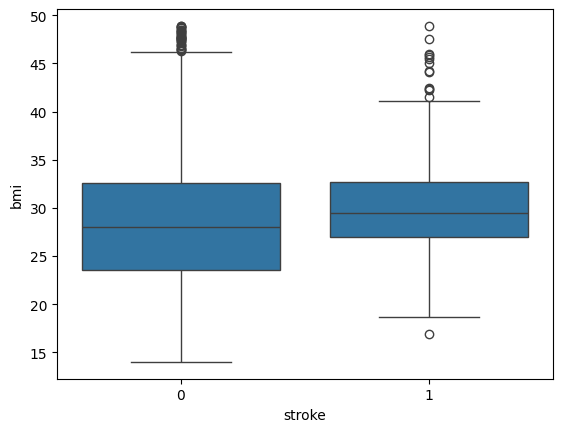

In [21]:
sns.boxplot(x='stroke', y='bmi', data=df)

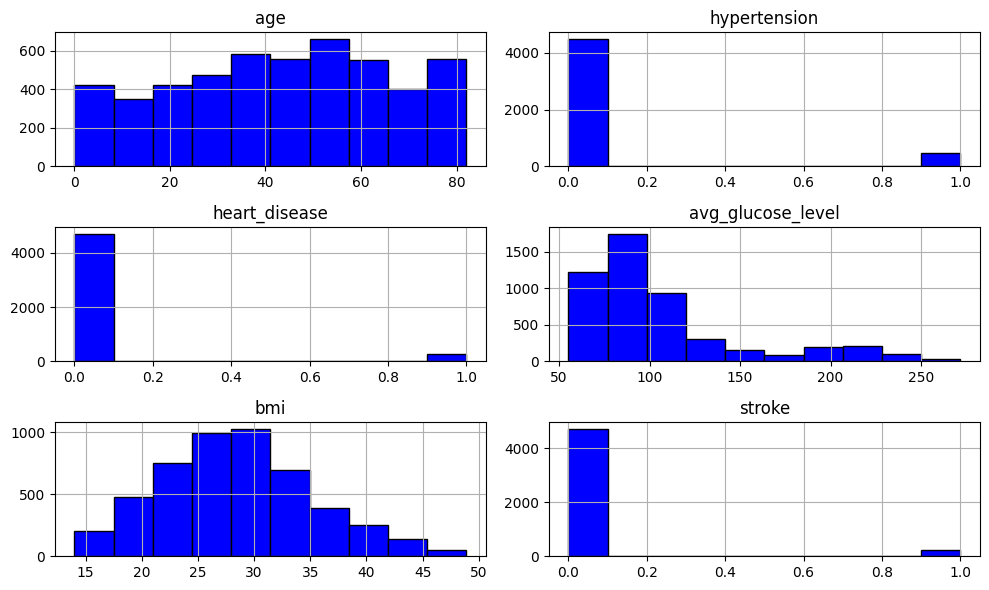

In [25]:
numericas= df.select_dtypes(include=['int64','float64']).columns
df[numericas].hist(figsize=(10,6), color='blue', edgecolor='black')
plt.tight_layout()
plt.show()

<Axes: >

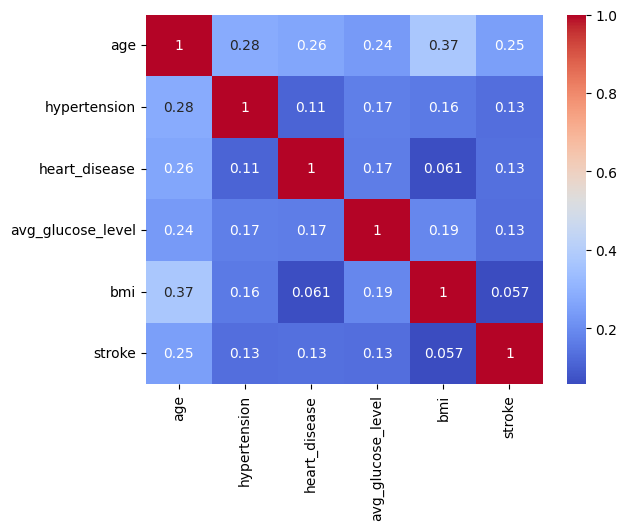

In [26]:
corr= df[numericas].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')

## Cramér's V Matrix for Categorical Variables
Association strength between categorical features using Cramér's V statistic


In [27]:
from scipy.stats import chi2_contingency
import numpy as np

def cramers_v(x, y, bias_correction=False):
    """
    Compute Cramér's V statistic for categorical association.
    
    Parameters:
    -----------
    x, y : array-like
        Categorical variables
    bias_correction : bool
        If True, applies Bergsma and Andries (2008) bias correction
        
    Returns:
    --------
    float : Cramér's V statistic (0 to 1)
    """
    # Create contingency table, handling missing values
    x_clean = pd.Series(x).fillna('Missing')
    y_clean = pd.Series(y).fillna('Missing')
    
    contingency = pd.crosstab(x_clean, y_clean)
    chi2, p, dof, expected = chi2_contingency(contingency)
    
    n = contingency.sum().sum()
    min_dim = min(contingency.shape) - 1
    
    if min_dim == 0:
        return 0.0
    
    # Standard Cramér's V
    v = np.sqrt(chi2 / (n * min_dim)) if n > 0 else 0.0
    
    if bias_correction:
        # Bergsma and Andries (2008) bias-corrected V
        phi2 = chi2 / n
        r, c = contingency.shape
        phi2_corr = max(0, phi2 - ((r - 1) * (c - 1)) / (n - 1))
        v_corr = np.sqrt(phi2_corr / (min(r, c) - 1)) if min(r, c) > 1 else 0.0
        return v_corr
    
    return v

# Get categorical columns
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
print(f"Categorical columns: {categorical_cols}")


Categorical columns: ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']


C:\Users\gemit\AppData\Local\Temp\ipykernel_23804\12287621.py:46: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()


In [28]:
# Compute Cramér's V matrix (standard version)
n_cat = len(categorical_cols)
cramers_matrix = np.zeros((n_cat, n_cat))

for i, col1 in enumerate(categorical_cols):
    for j, col2 in enumerate(categorical_cols):
        if i < j:  # Compute only upper triangle to avoid redundancy
            v = cramers_v(df[col1], df[col2], bias_correction=False)
            cramers_matrix[i, j] = v
            cramers_matrix[j, i] = v  # Fill symmetric position
        elif i == j:
            cramers_matrix[i, j] = 1.0  # Perfect association with itself

cramers_df = pd.DataFrame(cramers_matrix, 
                          index=categorical_cols, 
                          columns=categorical_cols)

print("\nCramér's V Matrix (Standard):")
print(cramers_df.round(3))



Cramér's V Matrix (Standard):
                gender  ever_married  work_type  Residence_type  \
gender           1.000         0.029      0.092           0.004   
ever_married     0.029         1.000      0.562           0.008   
work_type        0.092         0.562      1.000           0.021   
Residence_type   0.004         0.008      0.021           1.000   
smoking_status   0.105         0.346      0.300           0.036   

                smoking_status  
gender                   0.105  
ever_married             0.346  
work_type                0.300  
Residence_type           0.036  
smoking_status           1.000  


In [29]:
# Compute bias-corrected Cramér's V matrix
cramers_matrix_corrected = np.zeros((n_cat, n_cat))

for i, col1 in enumerate(categorical_cols):
    for j, col2 in enumerate(categorical_cols):
        if i < j:
            v_corr = cramers_v(df[col1], df[col2], bias_correction=True)
            cramers_matrix_corrected[i, j] = v_corr
            cramers_matrix_corrected[j, i] = v_corr
        elif i == j:
            cramers_matrix_corrected[i, j] = 1.0

cramers_corrected_df = pd.DataFrame(cramers_matrix_corrected, 
                                    index=categorical_cols, 
                                    columns=categorical_cols)

print("\nCramér's V Matrix (Bias-Corrected):")
print(cramers_corrected_df.round(3))



Cramér's V Matrix (Bias-Corrected):
                gender  ever_married  work_type  Residence_type  \
gender           1.000         0.025      0.088           0.000   
ever_married     0.025         1.000      0.562           0.000   
work_type        0.088         0.562      1.000           0.000   
Residence_type   0.000         0.000      0.000           1.000   
smoking_status   0.102         0.345      0.299           0.027   

                smoking_status  
gender                   0.102  
ever_married             0.345  
work_type                0.299  
Residence_type           0.027  
smoking_status           1.000  


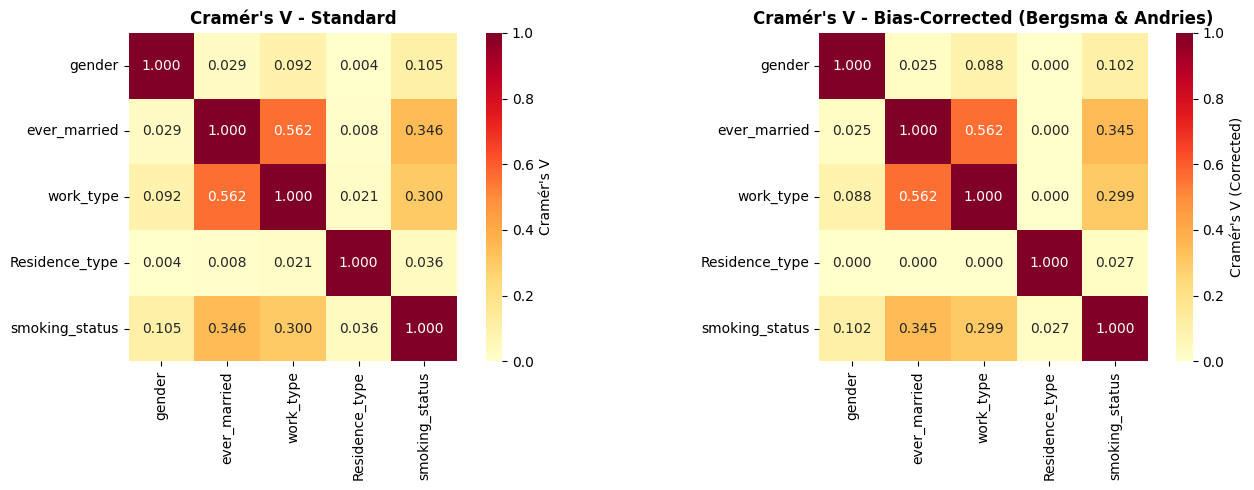

In [30]:
# Visualization: Heatmaps for both versions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Standard Cramér's V
sns.heatmap(cramers_df, annot=True, fmt='.3f', cmap='YlOrRd', 
            vmin=0, vmax=1, cbar_kws={'label': "Cramér's V"},
            ax=axes[0], square=True)
axes[0].set_title("Cramér's V - Standard", fontsize=12, fontweight='bold')

# Bias-Corrected Cramér's V
sns.heatmap(cramers_corrected_df, annot=True, fmt='.3f', cmap='YlOrRd',
            vmin=0, vmax=1, cbar_kws={'label': "Cramér's V (Corrected)"},
            ax=axes[1], square=True)
axes[1].set_title("Cramér's V - Bias-Corrected (Bergsma & Andries)", 
                  fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()


In [31]:
# Summary: Strongest associations between categorical variables
print("\n" + "="*60)
print("STRONGEST CATEGORICAL ASSOCIATIONS (Bias-Corrected)")
print("="*60)

# Extract upper triangle (avoid duplicates and diagonal)
mask = np.triu(np.ones_like(cramers_corrected_df, dtype=bool), k=1)
associations = []

for i in range(cramers_corrected_df.shape[0]):
    for j in range(i+1, cramers_corrected_df.shape[1]):
        associations.append({
            'Variable 1': categorical_cols[i],
            'Variable 2': categorical_cols[j],
            "Cramér's V": cramers_corrected_df.iloc[i, j]
        })

assoc_df = pd.DataFrame(associations).sort_values("Cramér's V", ascending=False)
print("\n", assoc_df.to_string(index=False))

print("\nInterpretation Guide:")
print("  V = 0.0-0.1 : Negligible association")
print("  V = 0.1-0.3 : Weak association")
print("  V = 0.3-0.5 : Moderate association")
print("  V = 0.5+    : Strong association")



STRONGEST CATEGORICAL ASSOCIATIONS (Bias-Corrected)

     Variable 1     Variable 2  Cramér's V
  ever_married      work_type    0.561595
  ever_married smoking_status    0.344911
     work_type smoking_status    0.299023
        gender smoking_status    0.101722
        gender      work_type    0.088263
Residence_type smoking_status    0.027005
        gender   ever_married    0.024776
        gender Residence_type    0.000000
  ever_married Residence_type    0.000000
     work_type Residence_type    0.000000

Interpretation Guide:
  V = 0.0-0.1 : Negligible association
  V = 0.1-0.3 : Weak association
  V = 0.3-0.5 : Moderate association
  V = 0.5+    : Strong association


In [32]:
pd.crosstab(df['smoking_status'], df['stroke'], normalize='index')

stroke,0,1
smoking_status,,
Unknown,0.968667,0.031333
formerly smoked,0.919262,0.080738
never smoked,0.951578,0.048422
smokes,0.945876,0.054124


In [33]:
pd.crosstab(df['work_type'], df['stroke'], normalize='index')

stroke,0,1
work_type,,
Govt_job,0.948758,0.051242
Private,0.948252,0.051748
Self-employed,0.919154,0.080846
children,0.997028,0.002972


In [34]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4981 entries, 0 to 4980
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gender             4981 non-null   str    
 1   age                4981 non-null   float64
 2   hypertension       4981 non-null   int64  
 3   heart_disease      4981 non-null   int64  
 4   ever_married       4981 non-null   str    
 5   work_type          4981 non-null   str    
 6   Residence_type     4981 non-null   str    
 7   avg_glucose_level  4981 non-null   float64
 8   bmi                4981 non-null   float64
 9   smoking_status     4981 non-null   str    
 10  stroke             4981 non-null   int64  
dtypes: float64(3), int64(3), str(5)
memory usage: 579.7 KB


In [64]:
df.loc[(df['age']<17) & (df['smoking_status'] == 'Unknown'), 'smoking_status'] = 'not_applied'

In [67]:
df.head(-30)

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
2,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
3,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
4,Male,81.0,0,0,Yes,Private,Urban,186.21,29.0,formerly smoked,1
...,...,...,...,...,...,...,...,...,...,...,...
4946,Male,1.8,0,0,No,children,Urban,68.80,18.7,not_applied,0
4947,Female,13.0,0,0,No,children,Rural,219.81,25.7,not_applied,0
4948,Female,61.0,0,0,Yes,Private,Rural,219.38,33.5,never smoked,0
4949,Female,37.0,0,0,No,Govt_job,Rural,72.08,29.6,formerly smoked,0


In [77]:
df['group'] = np.where(df['age']<17, 'children', 'adults')
df.head(-30)

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke,group
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1,adults
1,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1,adults
2,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1,adults
3,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1,adults
4,Male,81.0,0,0,Yes,Private,Urban,186.21,29.0,formerly smoked,1,adults
...,...,...,...,...,...,...,...,...,...,...,...,...
4946,Male,1.8,0,0,No,children,Urban,68.80,18.7,not_applied,0,children
4947,Female,13.0,0,0,No,children,Rural,219.81,25.7,not_applied,0,children
4948,Female,61.0,0,0,Yes,Private,Rural,219.38,33.5,never smoked,0,adults
4949,Female,37.0,0,0,No,Govt_job,Rural,72.08,29.6,formerly smoked,0,adults


In [79]:
df.loc[(df['work_type'] == 'children'), 'work_type'] = 'not_applied'
df.head(-30)

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke,group
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1,adults
1,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1,adults
2,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1,adults
3,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1,adults
4,Male,81.0,0,0,Yes,Private,Urban,186.21,29.0,formerly smoked,1,adults
...,...,...,...,...,...,...,...,...,...,...,...,...
4946,Male,1.8,0,0,No,not_applied,Urban,68.80,18.7,not_applied,0,children
4947,Female,13.0,0,0,No,not_applied,Rural,219.81,25.7,not_applied,0,children
4948,Female,61.0,0,0,Yes,Private,Rural,219.38,33.5,never smoked,0,adults
4949,Female,37.0,0,0,No,Govt_job,Rural,72.08,29.6,formerly smoked,0,adults


### Dataframe general One Hot Encode

In [80]:
df_encode= pd.get_dummies(df, drop_first=True)

In [81]:
df_encode.info()

<class 'pandas.DataFrame'>
RangeIndex: 4981 entries, 0 to 4980
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   age                             4981 non-null   float64
 1   hypertension                    4981 non-null   int64  
 2   heart_disease                   4981 non-null   int64  
 3   avg_glucose_level               4981 non-null   float64
 4   bmi                             4981 non-null   float64
 5   stroke                          4981 non-null   int64  
 6   gender_Male                     4981 non-null   bool   
 7   ever_married_Yes                4981 non-null   bool   
 8   work_type_Private               4981 non-null   bool   
 9   work_type_Self-employed         4981 non-null   bool   
 10  work_type_not_applied           4981 non-null   bool   
 11  Residence_type_Urban            4981 non-null   bool   
 12  smoking_status_formerly smoked  4981 non-null

In [82]:
df_encode.head(10)

,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke,gender_Male,ever_married_Yes,work_type_Private,work_type_Self-employed,work_type_not_applied,Residence_type_Urban,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_not_applied,smoking_status_smokes,group_children
0,67.0,0,1,228.69,36.6,1,True,True,True,False,False,True,True,False,False,False,False
1,80.0,0,1,105.92,32.5,1,True,True,True,False,False,False,False,True,False,False,False
2,49.0,0,0,171.23,34.4,1,False,True,True,False,False,True,False,False,False,True,False
3,79.0,1,0,174.12,24.0,1,False,True,False,True,False,False,False,True,False,False,False
4,81.0,0,0,186.21,29.0,1,True,True,True,False,False,True,True,False,False,False,False
5,74.0,1,1,70.09,27.4,1,True,True,True,False,False,False,False,True,False,False,False
6,69.0,0,0,94.39,22.8,1,False,False,True,False,False,True,False,True,False,False,False
7,78.0,0,0,58.57,24.2,1,False,True,True,False,False,True,False,False,False,False,False
8,81.0,1,0,80.43,29.7,1,False,True,True,False,False,False,False,True,False,False,False
9,61.0,0,1,120.46,36.8,1,False,True,False,False,False,False,False,False,False,True,False


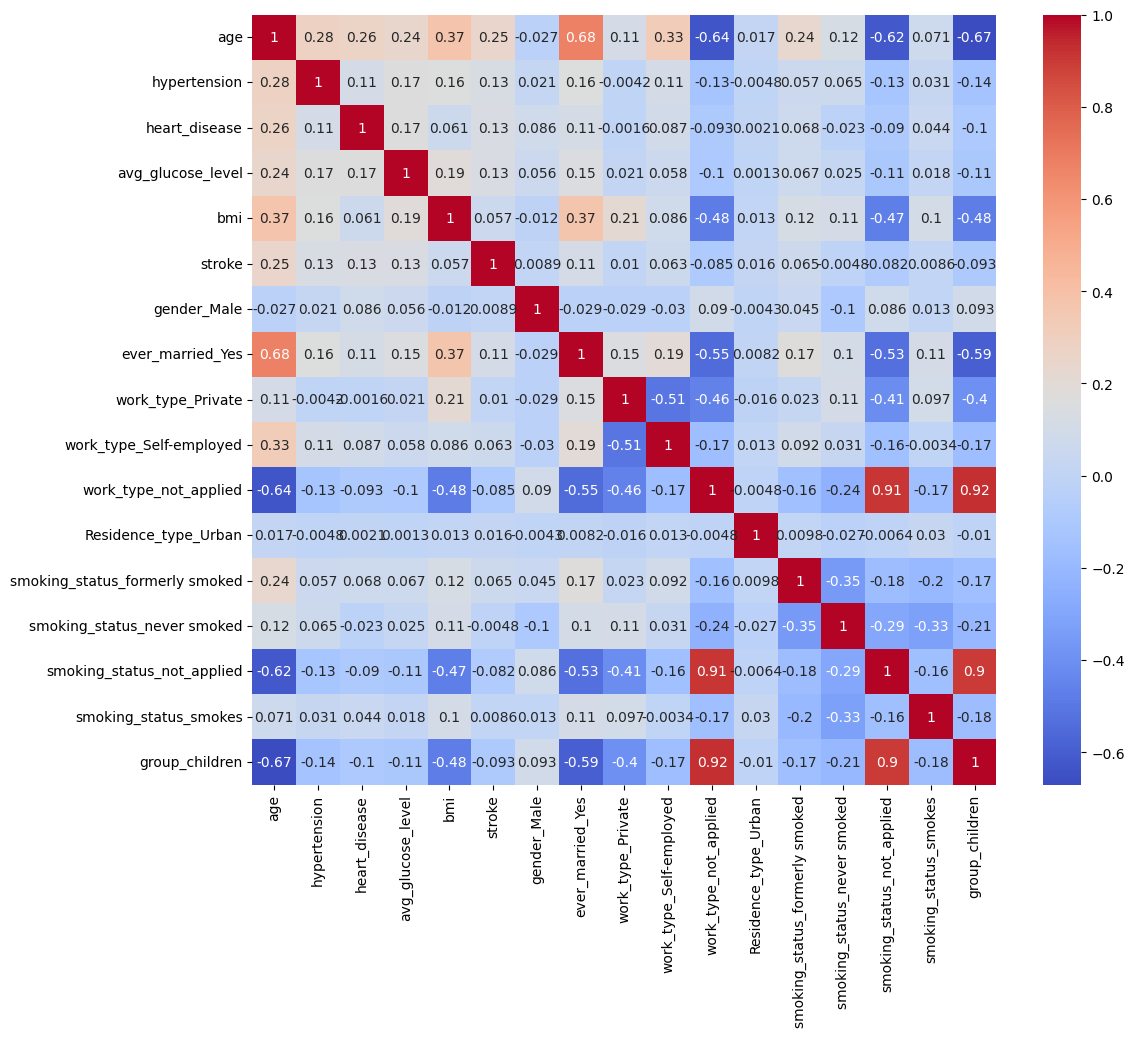

In [83]:
corr_matrix= df_encode.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, cmap='coolwarm', annot= True)
plt.show()

In [85]:
df_encode.to_csv('../data/processed/stroke_dataset_general.csv', index=False)

### Dataframe One Hot Encode solo con adultos

In [88]:
df_adultos= df[df['age']>16].copy()
df_adultos.drop(columns=['group'], inplace=True)
df_adultos.head(-30)

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
2,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
3,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
4,Male,81.0,0,0,Yes,Private,Urban,186.21,29.0,formerly smoked,1
...,...,...,...,...,...,...,...,...,...,...,...
4938,Female,49.0,0,0,Yes,Private,Rural,107.55,30.1,Unknown,0
4939,Male,52.0,0,1,No,Self-employed,Rural,79.81,30.2,formerly smoked,0
4940,Female,41.0,0,0,Yes,Self-employed,Rural,76.66,30.0,Unknown,0
4942,Male,34.0,0,0,Yes,Private,Urban,99.23,29.7,smokes,0


In [89]:
df_adultos.describe()

,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,4211.000000,4211.000000,4211.000000,4211.000000,4211.000000,4211.000000
mean,49.915222,0.113750,0.065068,107.994640,29.892567,0.058418
std,18.165188,0.317545,0.246675,47.331157,6.117804,0.234561
min,17.000000,0.000000,0.000000,55.120000,14.100000,0.000000
25%,35.000000,0.000000,0.000000,77.430000,25.500000,0.000000
50%,50.000000,0.000000,0.000000,92.230000,29.200000,0.000000
75%,64.000000,0.000000,0.000000,115.600000,33.500000,0.000000
max,82.000000,1.000000,1.000000,271.740000,48.900000,1.000000


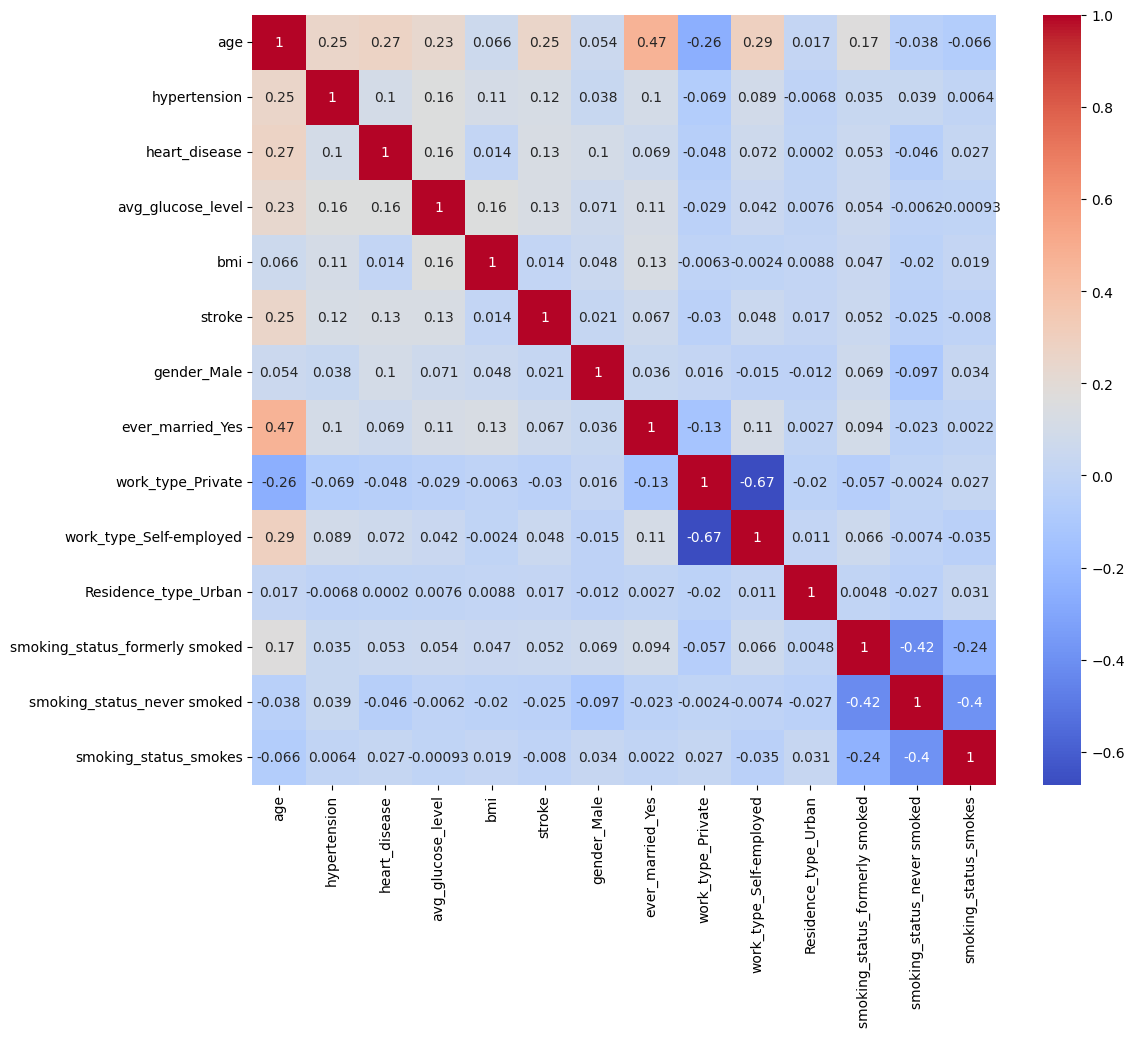

In [90]:
df_encode_adulto= pd.get_dummies(df_adultos, drop_first=True)
corr_matrix_adulto= df_encode_adulto.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix_adulto, cmap='coolwarm', annot= True)
plt.show()

In [91]:
df_encode_adulto.to_csv('../data/processed/stroke_dataset_adultos.csv', index=False)